# Optimització de models supervisats

Ja hem vist moltes millores als models supervisat i els algorismes més importants desenvolupats. Ara es tracta de millorar l'anàlisi per trobar els millors algorismes o hiperparàmetres.

Per exemple, en una regressió polinòmica s'ha de fixar el grau del polinomi amb un hiperparàmetre. Es pot anar provant el millor, però eixes proves es poden automatitzar. 

Molts models tenen hiperparàmetres, els valors dels quals cal fixar abans de començar el procés de
aprenentatge. Alguns com la regressió lineal no tenen hiperparàmetres perquè el resultat és el millor possible a un cost computacional molt gran per a moltes variables o moltes dades. Els algorismes més eficients com els basats en els descens de gradient tenen diferents resultats ens funció de criteris de parada d'entrenament o velocitat d'entrenament. 

## PipeLine

El procés d'entrenament manualment suposa tasques repetitives que poden donar lloc a errades. Si amés s'ha de fer una normalització o selecció de variables, per exemple, cada vegada, ens podem oblidar d'algun pas i el codi queda farragós. Es poden crear `Pipelines` amb totes les tasques ordenades com una `pipe` del paradigma de programació funcional i tractar eixe `pipeline` com un algorisme atòmic complet. 

Ací tenim un exemple amb una `Pipe` per a escalar, seleccionar el millor k i aplicar un model de machine learning. Amés, el pipeline se passa com a paràmetre a un GridSearchCV com un model qualsevol. En aquest capítol estan explicades aquestes tècniques:


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler


from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True)
X = data.data
y = data.target   # progresión de la enfermedad (variable continua)

print("Muestras:", X.shape[0])
print("Variables:", X.shape[1])

# Pipeline con ANOVA + modelo de regresión
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("anova", SelectKBest(score_func=f_regression)),
    ("model", Ridge())
])

# Valores candidatos de k
param_grid = {
    "anova__k": [2, 3, 5, 7, 10]
}

# GridSearch con validación cruzada
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X, y)

print("Mejor k:", grid.best_params_["anova__k"])
print("Mejor R² (CV):", grid.best_score_)


Muestras: 442
Variables: 10
Mejor k: 10
Mejor R² (CV): 0.4821936251213237


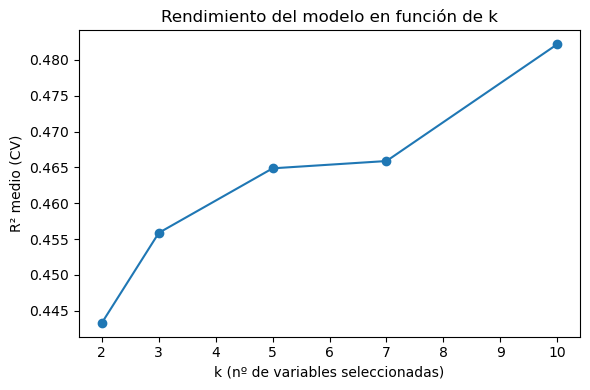

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(6, 4))
plt.plot(results["param_anova__k"], results["mean_test_score"], marker="o")
plt.xlabel("k (nº de variables seleccionadas)")
plt.ylabel("R² medio (CV)")
plt.title("Rendimiento del modelo en función de k")
plt.tight_layout()
plt.show()



## Hiperparàmetres i sobreajustament

Se'n mostra un exemple amb un model de regressió polinòmic. El valor de la variable target,
i es calcula amb un polinomi d'una variable predictora x. El grau del polinomi és un hiperparàmetre del
model. Amb valor 1 per a aquest hiperparàmetre, els únics models que es poden obtenir com a resultat del
procés d'entrenament són models lineals de la forma y = α0 + α1x. Si es fixa un valor de 2, es poden
obtenir models en què el valor de i es calcula amb un polinomi de segon grau, y = α0 + α1x + α2x2.

![ajust i sobreajust](./imgsclassificacio/ajust.png)

Una adequada selecció dels hiperparàmetres és determinant per obtenir un model apropiat per
un dataset. Els valors fixats per als hiperparàmetres restringeixen el conjunt de possibles models que es
poden obtenir com a resultat del procés daprenentatge i, per tant, la capacitat dobtenir un model
que s'ajuste a un dataset donat.

El primer dels tres models models anteriors pateix un ajustament insuficient a les dades (underfitting). Perquè un model de regressió lineal és massa senzill per a aquest dataset. L'últim és el que me
jor sajusta a les dades dentrenament, però segurament massa. Hi ha poques dades a la dreta, per
valors alts de la variable predictora, però tenen molta influència en la forma de la corba. Hi ha sobreajustament u overfitting, i aquest model no donarà tan bones prediccions per a dades noves com el segon. És necessàri, per tant, un compromís entre un bon ajustament a les dades d'entrenament i una generalitat suficient.

Tots els algorismes tant de classificació com de regressió que tinguen hiperparàmetres poden patir de sobreajust. En els exemples dels capítols inicials sols hem calculat la precisió com R² o la tassa d'encerts, però ara mirarem mètriques que avaluen si un model està sobreajustat o si és adeqüat per al problema com la precisió i el recall o matrius de confusió. 

Detecció de variables molt correlacionades

Detecció d'outliers


## Validació

En tots els algorismes que s'han vist es necessita la major precisió possible, però sense `Overfitting`. 

> Les representacions gràfiques també poden donar una idea de la qualitat, però a partir de 2 variables ja sols té sentit imprimir les mètriques.

És necessari obtenir unes mètriques de qualitat del model. En general, aquestes mètriques s'obtenen d'un conjunt de dades del dataset anomenat de `validació` o de `test`. Aquestes no seran utilitzades en els entrenaments de proves del model i, per tant, són dades noves en el moment del test. Que funcionen bé o molt paregut a les d'entrenament és una bona senyal de que el model ha generalitzat.

### Amb mostreig aleatori

Dividim el dataset en dades d'entrenament (`train`)  i de test. Sol estar d'un 20% a un 40%. La partició serà aleatoria. 

* Una bona precisió per a les dades d'entrenament indica un bon ajust del model.
* Si la precisió en les dades de tests no és molt pitjor que en el model indica que no hi ha sobreajust a les dades de l'entrenament. 

Com que es realitza una partició a l'atzar el resultat tant de l'entrenament com del test serà distint cada vegada. Inclús podrien donar-se falsos resultats molt bons per la distribució de les dades o més bons per al test que per a l'entrenament.

Com que es tracta de trobar els millors hiperparàmetres, normalment es poden calcular i dibuixar gràfiques de la qualitat del model en test i train amb distints valors dels hiperparàmetres per trobar el punt ideal. També cal tenir en compte l'objectiu del model i el compromís amb el rendiment. 

### Validació creuada (Cross Validation)

Limitacions del mostreig anterior:

* Els resultats depenen massa de l'atzar. Si el dataset és gran no és un gran problema.
* Si cal explorar varis hiperparàmetres es complica, si són més d'un fa falta un bucle niuat. 

Per evitar eixos problemes es poden fer varies particions distintes i treue la mitjana dels resultats. Però el problema és que pot ser que alguna mostra no es contemple mai a l'entrenament. 

La validació creuada fa un mostreig més sistematic: Fa k particions aleatories i entrena amb totes les combinacions de train i test agafant una partició de tests distinta cada vegada. D'aquesta manera es prova l'entrenament i el test amb totes les dades. El resultat és la mitjana dels resultats. 

## sample_weight

## GridSearchCV

En Scikit-Learn tenim `GridSearchCV` per a seleccionar els hiperparàmetres óptims. 

Permet indicar tots els possibles valors i combinacions de varis paràmetres i fer una validació creuada amb tots ells. 


## Early Stopping

Molts entrenaments són molt lents. Quan s'està fent un entrenament per descens de gradient, no sempre més iteracions impliquen una millora. De vegades no millora considerablements, de vegades arriba a un mínim local i de vegades inclús empijora perquè fa `Overfitting`. 

Per evitar eixos problemes o poder fer més proves en el mateix temps es pot implementar un entrenament oer etapes on s'avalua el model cada certs dades o iteracions i es decidexi si encara està millorant, si el model és suficientment bó o no val la pena seguir entrenant amb eixos hiperparàmetres. 

## Reducció de dimensionalitat

Aplicat a la preparació de les dades per a l'entrenament de models supervisats o no supervisats, la reducció de dimensionalitat ajuda a comprendre millor grans conjunts de dades amb moltes dimensions. Ens quedem amb l'informació esencial i eliminem la redundància. 

Es pot reduir seleccionant variables o projectant-les a un nou espai dimensional. 

En el capítol de l'entrenament no supervisat es veu en detall cóm funciona la reducció de dimensionalitat amb algorismes no supervisats com PCA, LDA

### Selecció de variables

Identificant les variables que expliquen o serveixen per predir l'objectiu i eliminant les que són irrellevants podem reduir dimensions de forma senzilla i millorem l'explicabilitat dels resultats.

El mètode **ANOVA** va un pas més enllà que les correlacions `Pearson` o `Spearman` explicant si una variable explica una alta. 

Aquest mètode ajusta un model senzill entre cada variable i el `target`. Separa la variabilitat total que és explicada de la variable objectiu. I avalua si la variabilitat és major que l'atzar. 

`ANOVA` funciona tant per a classificació com per a regressió. 

#### ANOVA per a Regressió



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import shap
shap.initjs()


from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True)
X = data.data
y = data.target   # progresión de la enfermedad (variable continua)

print("Muestras:", X.shape[0])
print("Variables:", X.shape[1])



Muestras: 442
Variables: 10


In [11]:
# Escalado de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled_df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568


Index(['bmi', 'bp', 's3', 's4', 's5'], dtype='object')


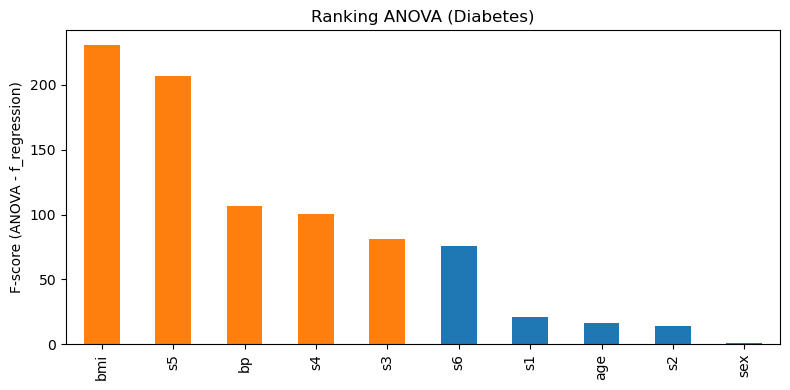

In [12]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=5)
X_anova = selector.fit_transform(X_scaled_df, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)


# Ranking ANOVA (f_regression)
anova_scores = pd.Series(
    selector.scores_,   # selector = SelectKBest(f_regression)
    index=X.columns
).sort_values(ascending=False)

# Visualización (resaltando las variables seleccionadas)
selected = set(selected_features)

colors = [
    "tab:orange" if feature in selected else "tab:blue"
    for feature in anova_scores.head(10).index
]

plt.figure(figsize=(8, 4))
anova_scores.head(10).plot(kind="bar", color=colors)
plt.ylabel("F-score (ANOVA - f_regression)")
plt.title("Ranking ANOVA (Diabetes)")
plt.tight_layout()
plt.show()



#### ANOVA per a classificació

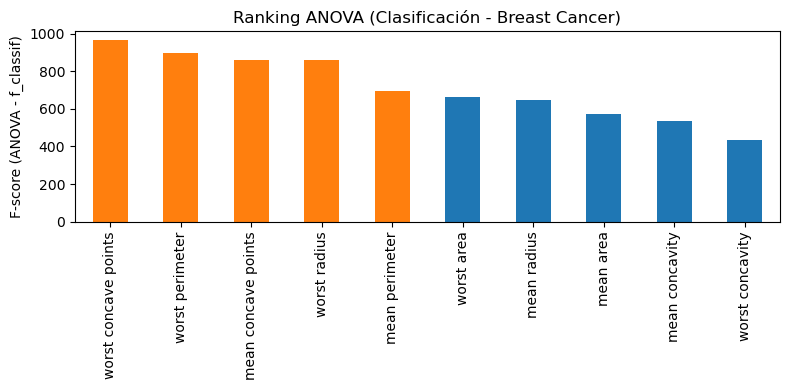

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset con nombres de variables
data = load_breast_cancer()
X_tmp = pd.DataFrame(data.data, columns=data.feature_names)
y_tmp = data.target

# ANOVA para clasificación
selector_tmp = SelectKBest(score_func=f_classif, k=5)
selector_tmp.fit(X_tmp, y_tmp)

# Variables seleccionadas
selected_features = X_tmp.columns[selector_tmp.get_support()]

# Ranking ANOVA
anova_scores = pd.Series(
    selector_tmp.scores_,
    index=X_tmp.columns
).sort_values(ascending=False)

# Visualización (resaltando las seleccionadas)
selected = set(selected_features)

colors = [
    "tab:orange" if feature in selected else "tab:blue"
    for feature in anova_scores.head(10).index
]

plt.figure(figsize=(8, 4))
anova_scores.head(10).plot(kind="bar", color=colors)
plt.ylabel("F-score (ANOVA - f_classif)")
plt.title("Ranking ANOVA (Clasificación - Breast Cancer)")
plt.tight_layout()
plt.show()




#### ANOVA amb selecció automàtica

Problema detectado: regresión


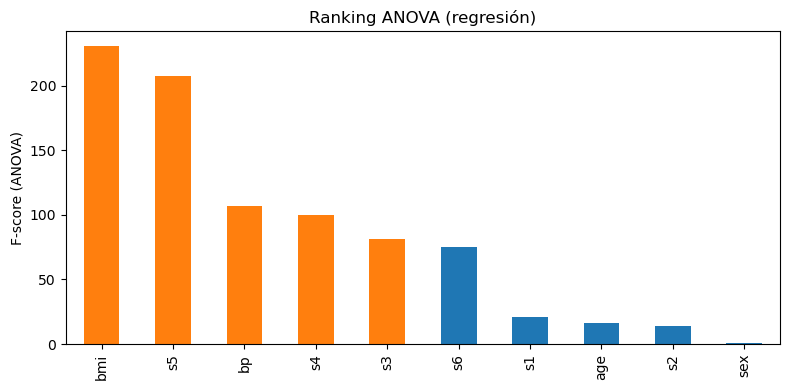

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression, f_classif

# Detección automática del tipo de problema
if np.issubdtype(y.dtype, np.integer) and pd.Series(y).nunique() < 20:
    score_func = f_classif
    problem_type = "clasificación"
else:
    score_func = f_regression
    problem_type = "regresión"

print(f"Problema detectado: {problem_type}")

# ANOVA automático
selector_auto = SelectKBest(score_func=score_func, k=5)
X_auto = selector_auto.fit_transform(X_scaled_df, y)

# Variables seleccionadas
selected_features = X.columns[selector_auto.get_support()]

# Ranking ANOVA (del selector automático)
anova_scores = pd.Series(
    selector_auto.scores_,
    index=X.columns
).sort_values(ascending=False)

# Visualización (resaltando las seleccionadas)
selected = set(selected_features)

colors = [
    "tab:orange" if feature in selected else "tab:blue"
    for feature in anova_scores.head(10).index
]

plt.figure(figsize=(8, 4))
anova_scores.head(10).plot(kind="bar", color=colors)
plt.ylabel("F-score (ANOVA)")
plt.title(f"Ranking ANOVA ({problem_type})")
plt.tight_layout()
plt.show()



Observa el codi de l'exemple del `Pipeline`.

Pot ser que k siga el màxim, en eixe cas, ANOVA ha decidit que fan falta totes les variables. Pot ser que siguen totes importants encara que una a una no aporten molta informació o perquè el `Ridge` ja porta la seua propia regularització i no es veu penalitzat per més dimensions. 

En ocasions l'informació rellevant està repartida en varies variables que una a una no tenen tanta importància, però no es poden eliminar. 

> La reducció de dimensionalitat sols s'ha d'aplicar quan millora el rendiment i la interpretabilitat i per a millorar l'eficiencia computacional.



Anem a crear un dataset amb noves variables de pur soroll. 

In [16]:
import numpy as np
import pandas as pd

# Semilla para reproducibilidad
np.random.seed(42)

# Filtrar variables numéricas (Diabetes ya lo es, pero se deja como plantilla)
X_num = X.select_dtypes(include=["number"])

# Número de variables de ruido
n_noise = 40

# Generación de variables irrelevantes
X_noise = pd.DataFrame(
    np.random.randn(len(X_num), n_noise),
    columns=[f"noise_{i}" for i in range(n_noise)],
    index=X_num.index
)

# Dataset aumentado con ruido
X_noisy = pd.concat([X_num, X_noise], axis=1)

X_noisy.shape


(442, 50)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

baseline_pipeline_noisy = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

baseline_noisy_scores = cross_val_score(
    baseline_pipeline_noisy,
    X_noisy,
    y,
    cv=5,
    scoring="r2",
    error_score="raise"
)

print("R² medio (sin ANOVA, con ruido):", baseline_noisy_scores.mean())
print("Desviación estándar:", baseline_noisy_scores.std())


R² medio (sin ANOVA, con ruido): 0.4198825989440321
Desviación estándar: 0.04819124810561998


R² sin ANOVA (con ruido): 0.4198825989440321
R² con ANOVA (con ruido): 0.46487625574786173
Mejor k: 5


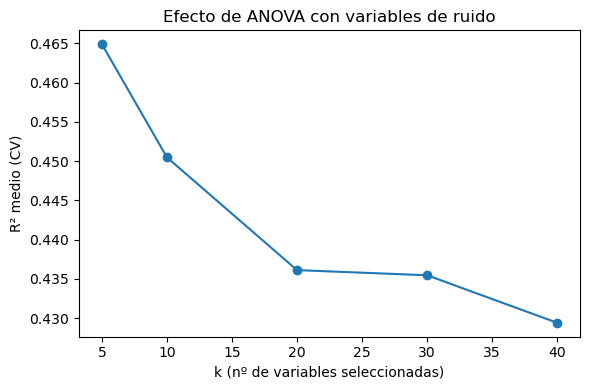

In [20]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV

pipeline_tmp_noisy = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("anova", SelectKBest(score_func=f_regression)),
    ("model", Ridge())
])

param_grid = {
    "anova__k": [5, 10, 20, 30, 40]
}

grid_noisy = GridSearchCV(
    pipeline_tmp_noisy,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    error_score="raise"
)

grid_noisy.fit(X_noisy, y)

grid_noisy.best_params_, grid_noisy.best_score_


print("R² sin ANOVA (con ruido):", baseline_noisy_scores.mean())
print("R² con ANOVA (con ruido):", grid_noisy.best_score_)
print("Mejor k:", grid_noisy.best_params_["anova__k"])

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid_noisy.cv_results_)

plt.figure(figsize=(6, 4))
plt.plot(results["param_anova__k"], results["mean_test_score"], marker="o")
plt.xlabel("k (nº de variables seleccionadas)")
plt.ylabel("R² medio (CV)")
plt.title("Efecto de ANOVA con variables de ruido")
plt.tight_layout()
plt.show()



El F score permet ordenar les variables per la seua capacitat explicativa individual:

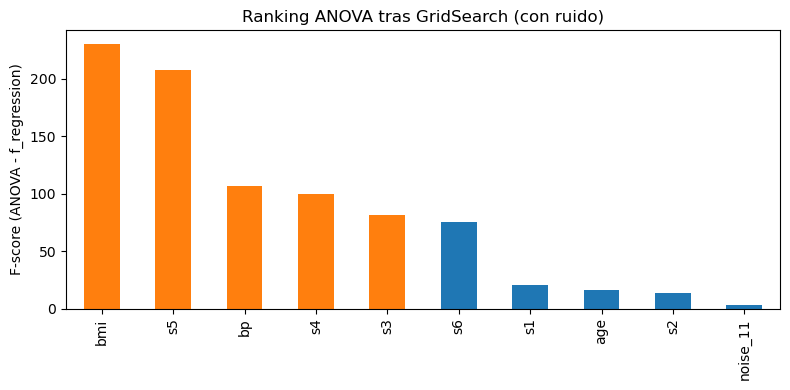

In [21]:
# Extraer el pipeline óptimo
best_pipeline = grid_noisy.best_estimator_

# Extraer el selector ANOVA entrenado
selector_best = best_pipeline.named_steps["anova"]

# Variables seleccionadas
selected_features = X_noisy.columns[selector_best.get_support()]

# Ranking ANOVA (coherente con X_noisy)
anova_scores = pd.Series(
    selector_best.scores_,
    index=X_noisy.columns
).sort_values(ascending=False)

# Visualización (resaltando las seleccionadas)
selected = set(selected_features)

colors = [
    "tab:orange" if feature in selected else "tab:blue"
    for feature in anova_scores.head(10).index
]

plt.figure(figsize=(8, 4))
anova_scores.head(10).plot(kind="bar", color=colors)
plt.ylabel("F-score (ANOVA - f_regression)")
plt.title("Ranking ANOVA tras GridSearch (con ruido)")
plt.tight_layout()
plt.show()


La validació creauada ha permes seleccionar el k de variables que maximitza la regressió. 

És el punt de compromís entre la complexitat i la seua capacitat. 

Si k és alt, en aquest cas incorpora el soroll, si és massa baix elimina informació rellevant. 

> En l'exemple R² no és alt per la complexitat del problema i el model lineal simple triat.

In [24]:
import pandas as pd



results = pd.DataFrame({
    "Escenario": [
        #"Sin ruido (baseline)",
        "Con ruido (sin ANOVA)",
        "Con ruido + ANOVA"
    ],
    "R² medio (CV)": [
        #baseline_scores.mean(),          # sin ruido
        baseline_noisy_scores.mean(),    # con ruido
        grid_noisy.best_score_           # con ruido + ANOVA
    ]
})


results


,Escenario,R² medio (CV)
0,Con ruido (sin ANOVA),0.419883
1,Con ruido + ANOVA,0.464876


In [25]:
# Entrenamiento final del pipeline con k óptimo
best_pipeline = grid_noisy.best_estimator_
best_pipeline.fit(X_noisy, y)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](50,)","['age','sex','bmi',...,'noise_37','noise_38','noise_39']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,50
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy 

In [26]:
selected_mask = best_pipeline.named_steps["anova"].get_support()
selected_features = X_noisy.columns[selected_mask]

selected_features


Index(['bmi', 'bp', 's3', 's4', 's5'], dtype='object')

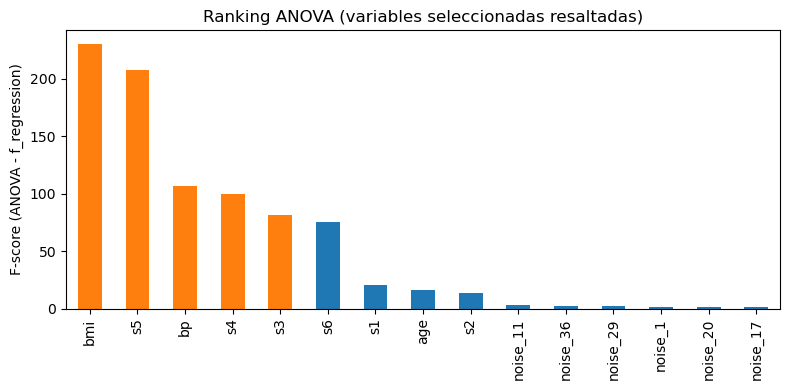

In [27]:
anova_scores = pd.Series(
    best_pipeline.named_steps["anova"].scores_,
    index=X_noisy.columns
).sort_values(ascending=False)

selected = set(selected_features)

colors = [
    "tab:orange" if feature in selected else "tab:blue"
    for feature in anova_scores.head(15).index
]

plt.figure(figsize=(8, 4))
anova_scores.head(15).plot(kind="bar", color=colors)
plt.ylabel("F-score (ANOVA - f_regression)")
plt.title("Ranking ANOVA (variables seleccionadas resaltadas)")
plt.tight_layout()
plt.show()


### Explicabilitat amb SHAP

Si hem utilitzar ANOVA per obtenir les k millors variables i entrenat el model, cal explicar cóm afecta cada variable a les prediccions. 

In [28]:
X_selected = X[selected_features]


In [29]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()
final_model.fit(X_selected, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 560.58, 268.6 ,-273.26,-137.5 , 536.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['bmi','bp','s3','s4','s5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [30]:
import shap
shap.initjs()

explainer = shap.Explainer(final_model, X_selected)
shap_values = explainer(X_selected)


Background dataset has 442 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=442 when initializing the masker.


/tmp/ipykernel_10188/667018264.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_selected)


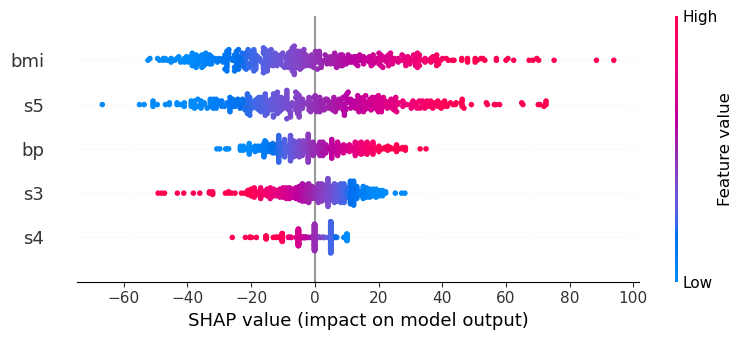

In [31]:
shap.summary_plot(shap_values, X_selected)


El `summary_plot` mostra la importància global de cada variable el sentit positiu o negatiu i la distribució dels efectes. 

En aquest exemple es veu que:

* bmi és la variable més rellevant.
* L'eix horizontal indica l'impacte de cada variable sobre la predicció. Els valors alts incrementen la predicció i els baixos la redueixen. Per tant bmi i s5 amb valors alts són molt influyents en la predicció positiva i els valors baixos impacten en la reducció de la predicció. 
* Els colors indiquen el valor de les variables, en roig són alts i en blau baixos. bp té una influència menor, però en el mateix sentit que les anteriors mentre que s3 i s4 tenen un efecte invers, si incrementa una variable, la predicció es decrementa. 

En aquest moment podriem treue una explicació del model:

El model basa les seues prediccións en l'estat del pacient. La variable que més influencia té és l'index de massa corporal o `bmi`. Els indicadors metabólics (s5) també són molt rellevants. La presió arterial (bp) alta també pot ser un factor rellevant. Per una altra banda S3 i S4 tenen menor influència i els valors baixos incrementen lleugerament les probabilitats de predicció de la diabetes. 

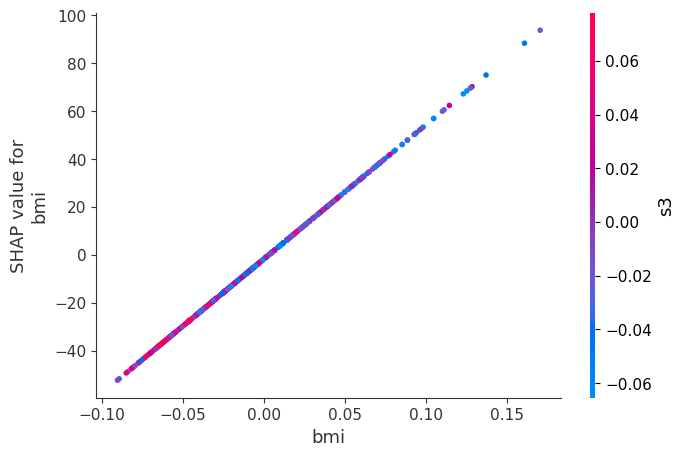

In [41]:
shap.dependence_plot("bmi", shap_values.values, X_selected)


En el cas de la variable `bmi`, el `dependence_plot` indica cóm varia la seua contribució a la predicció del model. Té sentit que siga una recta al ser un model lineal. 

Es veu que els valors baixos generen contribucions negatives perquè el color es veu més roig a la part de baix. El color del punts mostra una dispersió limitada. 

Per tant podem concloure que `bmi` és una variable clau i el seu efecte en la predicció és extable, monotónic i molt lineal. Aquest gràfic permet detectar relacions no lineals que no siguen evidents.

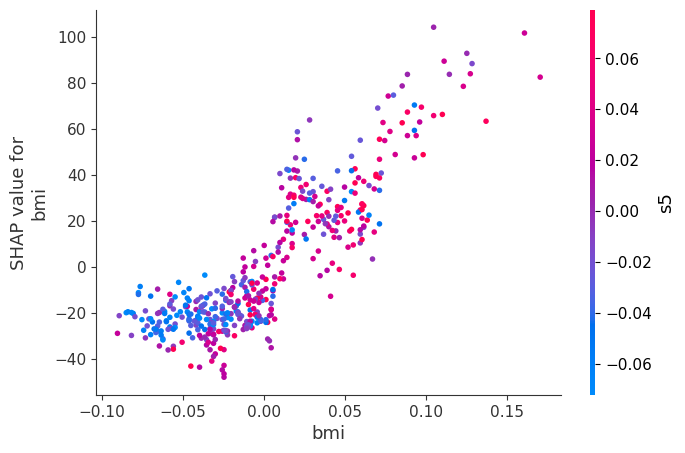

In [39]:
from sklearn.ensemble import RandomForestRegressor
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_selected, y)

# 1. Creem l'explorador específic per a arbres
explainer_rf = shap.TreeExplainer(rf)

# 2. Calculem els valors SHAP desactivant l'additivitat
shap_values_rf = explainer_rf(X_selected, check_additivity=False)

shap.dependence_plot(
    "bmi",
    shap_values_rf.values,
    X_selected
)


Utilitzant un model `Random Forest` que no és lineal es veu que l'influència és gran i majorment lineal. 

S'observa que té una tendència creixent però amb dispersió i variabilitat local. 

En general els valors baixos tenen una contribució negativa reduint la predicció de l'enfermetat.

En valors intermedis l'impacte augmenta de manera més pronunciada, detectant `umbrals` o regions on l'efecte s'intensifica. 

La dispersio `vertical` indica que l'impacte depen d'altre variables, cosa normal en un model no lineal. 

El gradient de color indica que l'efecte de `bmi` varia en funció de `s5`, sugerint una `interacció` entre les variables. Per a valors alts de `S5`, l'impacte de `bmi` tendeix a ser major. 

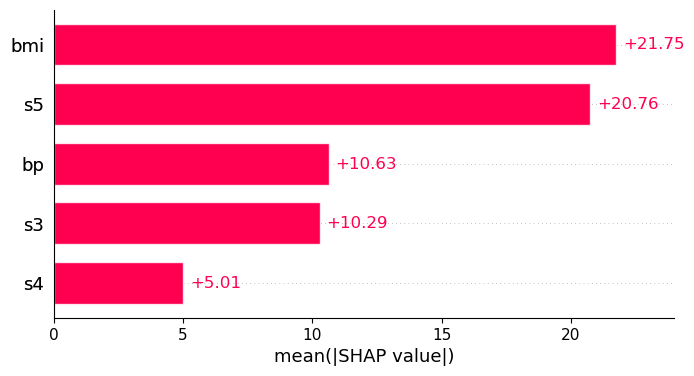

In [40]:
# Bar plot de SHAP: importancia global de las variables
shap.plots.bar(shap_values)


El `bar_plot` indica l'importància global de cada variable agregant el valor mitjà absolut dels seus valors SHAP.

No dona detalls, però por ser utilitzat en informes finals per confirmar que ANOVA ha funcionat bé. 

El resultat és coherent amb el `summary_plot` en l'ordre de les variables.

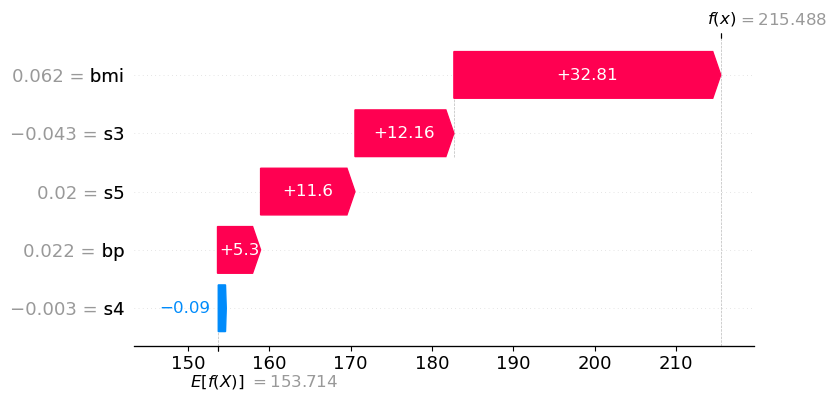

In [42]:
# Waterfall plot SHAP: explicación de una predicción individual

# Elegir una observación (por ejemplo, la primera)
i = 0

shap.plots.waterfall(
    shap_values[i]
)


El `waterfall plot` mostra com cada variable "espenta" en la decisió d'una única predicció. Es veu quines variables augmenten o disminueixen una variable. 

Por servir per detallar un pacient en concret com a informació útil per a la decisió humana final. 

`E[f(X)]` representa la predicció mitjana en tot el conjunt de dades. 

Es veu que `bmi` és la que més incrementa la predicció i cóm s3 i s5 tenen una contribució menor en la mateixa direcció. L'efecte de bp és més moderat en aquest cas. s4 te un impacte negatiu però quasi insignificant. 

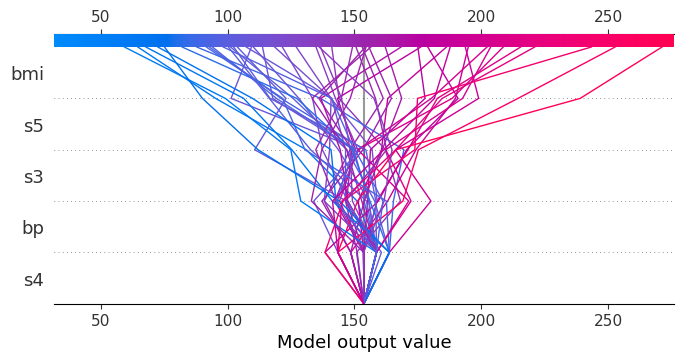

In [43]:
# Decision plot SHAP: proceso de decisión del modelo (regresión)

idx = range(50)

shap.decision_plot(
    shap_values.base_values.mean(),   # valor base escalar
    shap_values.values[idx],
    feature_names=list(X_selected.columns)
)


Mostra cóm es va construint una decisió en funció de la contribució de cada variable. En aquest cas es mostren 50 observacions. 

Permet visualitzar trajectòries de decisions, cóm les variables afecten a la decisió final. Ajuda a detectar variables dominants, efectes acumulatius i patrons comuns. 

Es veu que bmi i s5 són els que majors desplaçaments provoquen. 

In [44]:
# Force plot SHAP: explicación individual visual
import shap
shap.initjs()

# Seleccionar una observación
i = 0

shap.plots.force(
    shap_values.base_values[i],
    shap_values.values[i],
    X_selected.iloc[i]
)


El `force_plot` és també per a una variable i el que mostra eś molt paregut al `waterfall` 

Exemple complet:

In [45]:
import shap
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# 1) Cargar datos
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

# 2) Pipeline simple (lineal, interpretable)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipeline.fit(X, y)

# 3) SHAP
X_scaled = pipeline.named_steps["scaler"].transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

explainer = shap.Explainer(pipeline.named_steps["model"], X_scaled_df)
shap_values = explainer(X_scaled_df)

# 4) Buscar una observación con contribuciones positivas y negativas
i = np.where(
    (shap_values.values > 0).any(axis=1) &
    (shap_values.values < 0).any(axis=1)
)[0][0]

# 5) Force plot
shap.initjs()
shap.plots.force(
    shap_values.base_values[i],
    shap_values.values[i],
    X.iloc[i]
)


Background dataset has 442 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=442 when initializing the masker.
